In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../pyCudaPolygon"))
import pyCudaPolygon as pcp
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from pyCudaPolygonLink import libpyCudaPolygon as lpcp

In [2]:
maxSteps = 20

<Figure size 640x480 with 0 Axes>

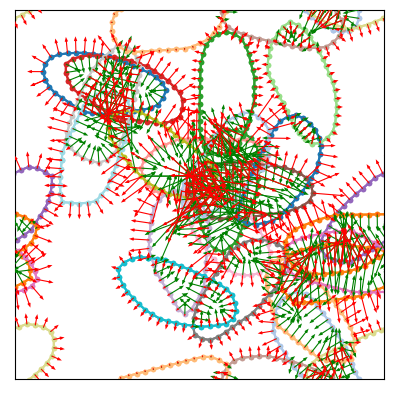

In [3]:
numPolygons = 25
n = 35
nVals = [0, 1, 2, 3, 9,4 ,5, 6, 20, 25, 35, 54]
i = 7
phi = 1.0
kappa = 4.0
m = pcp.model(size = n * numPolygons, seed = i)
m.setModelEnum("normal")
m.generateRandomPolygons(numPolygons, n, kappa = kappa, phi = phi)
positions = m.getPositions()
positions[1::2] += 0.4
positions %= 1
m.setPositions(positions)
#modelDir = "minCheckpointRestart2/" + str(np.max(np.array(os.listdir("minCheckpointRestart2")).astype(int)))
#m.loadModel(modelDir)
plt.clf()
# Works fine
m.setMaxEdgeLength()
# use default max edge length by finding it within the simulation
# You can adjust this later.
m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors()
m.updateOutersections()
m.updateForceEnergy()
forceTest = m.getForces()
m.updateConstraintForces()
forceTest0 = m.getConstraintForces()
#forceTest0 = m.getConstrainedForce(forceTest)
#print(np.max(np.abs(force - forceTest)))
#force0 = m.getConstrainedForce(force)
positions0 = m.getPositions()
fig, ax = plt.subplots()
artists = m.draw(ax = ax, forces = forceTest, arrowColor = 'g', numbering = False)
artists2 = m.draw(ax = ax, forces = forceTest0, arrowColor = 'r', numbering = False)